<h2>Predviđanje nivoa zavisnosti od mobilnih telefona - 2. Modeli</h2>
<h3>Uvod</h3>

U drugom delu rada, bavićemo se treniranjem i evauluacijom performansi različitih modela poput: Linearne regresije, XGBoost, KNN, i MLP NN. Za modele koje se najbolje pokažu ćemo uraditi feature engineering, kao i optimizaciju hiperparametara.

<h3>Pretprocesiranje</h3>

Za početak nedostajuće vrednosti i duplikati nisu pronadjeni. Atribut School_Grade čije su vrednosti bile redni brojevi na engleskom, su prebačeni u brojeve ('Seventh' -> 7). Kolona Location je izbačena jer nema nikakav uticaj na posmatranje problema zavisnosti. Za atribute Phone_Usage_Purpose i Gender je iskorišćen One hot encoding kako bi se pretvorile kategoričke vrednosti. U inicijalni skup podataka dodati su podaci izvršene ankete kako bi se smanjila nebalansiranost ciljnog obeležja i omogućilo modelu da bolje uoči zavisnosti između ulaznih karakteristika i nivoa zavisnosti.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("src"))

import preprocessing

df = pd.read_csv("data/podaci.csv")
print(f"Dimenzija tabele: {df.shape}\n")

df['School_Grade'] = df['School_Grade'].astype(str).str.replace(r'th|st|nd|rd', '', regex=True)
df['School_Grade'] = pd.to_numeric(df['School_Grade'], errors='coerce')
df['School_Grade'] = df['School_Grade'].fillna(0).astype(int)

df = df.drop(columns=['Location'])

new_df = pd.read_csv("data/podaci_ankete.csv")
new_df = new_df.drop(columns=['Timestamp'])
new_df = new_df.fillna(0)
new_df.head()

merged = preprocessing.merge_datasets(df, new_df)
# merged.to_csv('data/merged.csv', index=False)

df_processed = preprocessing.preprocess(merged)

print(f"\nNova dimenzija tabele: {df_processed.shape}")
print("\nPrvih 5 redova enkodiranih podataka:")
display(df_processed.head())

Dimenzija tabele: (3000, 25)

Nema nedostajućih vrednosti.

Nema duplikata.

Nova dimenzija tabele: (3099, 21)

Prvih 5 redova enkodiranih podataka:


,Age,Daily_Usage_Hours,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Screen_Time_Before_Bed,Weekend_Usage_Hours,Sleep_Hours,Anxiety_Level,...,Family_Communication,Exercise_Hours,Academic_Performance,Addiction_Level,Gender_Male,Gender_Other,Phone_Usage_Purpose_Education,Phone_Usage_Purpose_Gaming,Phone_Usage_Purpose_Other,Phone_Usage_Purpose_Social Media
0,13,4.0,86,19,3.6,1.7,1.4,8.7,6.1,10,...,4,0.1,78,10.0,False,False,False,False,False,False
1,17,5.5,96,9,1.1,4.0,0.9,5.3,6.5,3,...,2,0.0,70,10.0,False,False,False,False,False,False
2,13,5.8,137,8,0.3,1.5,0.5,5.7,5.5,2,...,6,0.8,93,9.2,False,True,True,False,False,False
3,18,3.1,128,7,3.1,1.6,1.4,3.0,3.9,9,...,8,1.6,78,9.8,False,False,False,False,False,True
4,14,2.5,96,20,2.6,0.9,1.0,3.7,6.7,1,...,10,1.1,56,8.6,False,True,False,True,False,False


<h3> Treniranje Linearne Regresije i XGBoost-a</h3>

Delimo podatke na trening i test skup u odnosu 70:30. 

Zbog malog broja podataka koristi se K-Fold cross-validation, dok se težinska regresija primenjuje da se ublaži asimetričnost ciljnog obeležja. 

K-fold (5 fold) split deli podatke na 5 delova, od kojih će 4 biti za trening i jedan za validaciju treniranih modela. Za svaki od trening foldova se trenira odvojen model i čuvaju rezultati dobijeni korišćenjem validacionog skupa. 

Metoda omogućava i dodavanje težina pri treniranju. Testiranjem različitih metoda dodavanja težina, odabrana je Log-smoothed inverse frequency, jer najbolje očuvava performanse modela, a efikasno ublažava asimteriju u raspodeli podataka.

$$
w_i = \log\left(1 + \frac{N}{c_{y_i}} \right)
$$

gde je:

- $N$ - ukupan broj uzoraka u trening skupu  
- $c_{y_i}$ - broj pojavljivanja klase kojoj pripada uzorak $i$  
- $w_i$ - težina dodeljena uzorku $i$

Pored težinske regresije, implementirana je i varijacija koja koristi SMOTE (Synthetic Minority Over-sampling Technique) metodu za balansiranje skupa podataka. Iako se SMOTE primarno koristi u klasifikaciji, ovde je prilagođen regresionom problemu pomoću zaokruživanja ciljne promenljive. Na ovaj način se retki opsezi nivoa zavisnosti proširuju interpolacijom novih sintetičkih uzoraka unutar tih opsega.

Konačni rezultat predstavljaju proseci po foldovima za metrike MAE, RMSE i R2. 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import models

X = df_processed.drop(columns=['Addiction_Level', 'ID', 'Name'], errors='ignore')
y = df_processed['Addiction_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treniranje sa K-Fold validacijom
_ = models.train_model_with_cv(LinearRegression(), X_train, y_train)
_ = models.train_model_with_cv(LinearRegression(), X_train, y_train, use_weights=True)
_ = models.train_model_with_cv(LinearRegression(), X_train, y_train, use_smote=True)

c:\Users\Strahinja\Desktop\SIAP Projekat\siap-projekat\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



===== LinearRegression (K-Fold Standard) =====
CV MAE: 0.7245 | RMSE: 0.9477 | R2: 0.6923

===== LinearRegression (K-Fold Weighted) =====
CV MAE: 0.7678 | RMSE: 0.9999 | R2: 0.6569

===== LinearRegression (K-Fold SMOTE) =====
CV MAE: 0.9067 | RMSE: 1.2467 | R2: 0.4556


In [3]:
_ = models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train)
_ = models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=True)
_ = models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_smote=True)


===== XGBRegressor (K-Fold Standard) =====
CV MAE: 0.4160 | RMSE: 0.6573 | R2: 0.8509

===== XGBRegressor (K-Fold Weighted) =====
CV MAE: 0.4225 | RMSE: 0.6525 | R2: 0.8526

===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 0.4560 | RMSE: 0.6906 | R2: 0.8351


Pored metoda balansiranja, istražena je i mogućnost transformacije ciljne promenljive (logaritamska i stepena transformacija) u cilju normalizacije distribucije i smanjenja uticaja ekstremnih vrednosti. 

In [4]:
models.train_model_with_transformation_cv(XGBRegressor(random_state=42), X_train, y_train, method='power')
models.train_model_with_transformation_cv(XGBRegressor(random_state=42), X_train, y_train, method='log')


===== XGBRegressor (K-Fold POWER Transformed) =====
CV Prosečan MAE: 0.4078
CV Prosečan R2 Score: 0.8628

===== XGBRegressor (K-Fold LOG Transformed) =====
CV Prosečan MAE: 0.4258
CV Prosečan R2 Score: 0.8475


Možemo uočiti da XGBoost u svim varijacijama daje znatno bolje rezultate od Linearne regresije, i zbog toga ćemo taj model koristiti za finalnu evaluaciju. Takođe možemo primetiti mali pad u performansama pri korišćenju težina i SMOTE, što je i očekivano. Ovi modeli će bolje prediktovati manje prisutne nivoe zavisnosti, po cenu malog pada u performansama.

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

knn = KNeighborsRegressor(n_neighbors=7, p=2, weights='distance')

_ = models.train_model_with_cv(knn, X_train, y_train, use_smote=True, use_scaling=True)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='tanh',
    alpha=0.0001,
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

_ = models.train_model_with_cv(mlp, X_train, y_train, use_smote=True, use_scaling=True)


===== KNeighborsRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 1.0815 | RMSE: 1.4299 | R2: 0.2842

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.1617 | RMSE: 0.4433 | R2: 0.9266


Na osnovu kros-validacije, jasno se izdvajaju razlike između lokalnih i globalnih modela. MLP daje najbolje rezultate dosad (R² > 0.90), što ukazuje na njegovu sposobnost da modeluje složene nelinearne odnose. Nasuprot tome, kNN ostvaruje slabe rezultate (R² ≈ 0.27), pre svega zbog prokletstva dimenzionalnosti.

Dalji rad fokusira se na MLP i XGBoost kao najperspektivnije modele. Sledeći korak je dodatno poboljšanje ova dva modela, pomoću optimizacije hiperparametara. Isprobaćemo različite kombinacije parametara, kako bismo dobili model sa najboljim rezultatima. U ovom procesu će se ponoviti ceo pipeline treniranja kao i dosad. 

In [6]:
best_xgb_mae = float('inf')
best_xgb_params = {}

for depth in [3, 5, 7]:
    for lr in [0.01, 0.1]:
        print(f"Testiram XGB: depth={depth}, lr={lr}...")
        current_mae = models.train_model_with_cv(
            XGBRegressor(max_depth=depth, learning_rate=lr, random_state=42),
            X_train, y_train, use_smote=True, use_scaling=False
        )
        if current_mae < best_xgb_mae:
            best_xgb_mae = current_mae
            best_xgb_params = {'max_depth': depth, 'learning_rate': lr}

print(f"\nNajbolji XGB: {best_xgb_params}")

Testiram XGB: depth=3, lr=0.01...

===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 1.7891 | RMSE: 1.9936 | R2: -0.4291
Testiram XGB: depth=3, lr=0.1...

===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 0.5694 | RMSE: 0.7785 | R2: 0.7876
Testiram XGB: depth=5, lr=0.01...

===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 1.5529 | RMSE: 1.7390 | R2: -0.0811
Testiram XGB: depth=5, lr=0.1...

===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 0.4475 | RMSE: 0.6572 | R2: 0.8508
Testiram XGB: depth=7, lr=0.01...

===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 1.4234 | RMSE: 1.5993 | R2: 0.0887
Testiram XGB: depth=7, lr=0.1...

===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 0.4177 | RMSE: 0.6540 | R2: 0.8512

Najbolji XGB: {'max_depth': 7, 'learning_rate': 0.1}


XGBoost model sa najmanjim MAE ima vrednost hiperparametara max_depth = 7 i learning_rate = 0.1. Max_depth podrazumeva maksimalnu dubinu stabla, dublje stablo omogućava modelu da uči kompleksnije obrasce u podacima. Learning rate 0.01 je prespor, i vrednost 0.1 je omogućila bržu konvergenciju.

In [7]:
layers_list = [(64, 32), (128, 64, 32)]
alphas = [0.0001, 0.01]
activations = ['relu', 'tanh']
learning_rates = [0.001, 0.01]

best_mlp_mae = float('inf')
best_mlp_params = {}

for layers in layers_list:
    for a in alphas:
        for act in activations:
            for lr in learning_rates:
                print(f"\nTestiram MLP: layers={layers}, alpha={a}, act={act}, lr={lr}...")
                
                current_mae = models.train_model_with_cv(
                    MLPRegressor(
                        hidden_layer_sizes=layers, 
                        alpha=a, 
                        activation=act, 
                        learning_rate_init=lr,
                        max_iter=1000, 
                        random_state=42
                    ),
                    X_train, y_train, use_smote=True, use_scaling=True
                )
                
                if current_mae < best_mlp_mae:
                    best_mlp_mae = current_mae
                    best_mlp_params = {
                        'hidden_layer_sizes': layers, 
                        'alpha': a,
                        'activation': act,
                        'learning_rate_init': lr
                    }

print(f"\nNAJBOLJI MLP PARAMETRI: {best_mlp_params}")
print(f"NAJBOLJI CV MAE: {best_mlp_mae:.4f}")


Testiram MLP: layers=(64, 32), alpha=0.0001, act=relu, lr=0.001...

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.2371 | RMSE: 0.5088 | R2: 0.9035

Testiram MLP: layers=(64, 32), alpha=0.0001, act=relu, lr=0.01...

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.2707 | RMSE: 0.5095 | R2: 0.9078

Testiram MLP: layers=(64, 32), alpha=0.0001, act=tanh, lr=0.001...

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.1705 | RMSE: 0.4245 | R2: 0.9301

Testiram MLP: layers=(64, 32), alpha=0.0001, act=tanh, lr=0.01...

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.1617 | RMSE: 0.4433 | R2: 0.9266

Testiram MLP: layers=(64, 32), alpha=0.01, act=relu, lr=0.001...

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.2298 | RMSE: 0.5075 | R2: 0.9048

Testiram MLP: layers=(64, 32), alpha=0.01, act=relu, lr=0.01...

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.2453 | RMSE: 0.4932 | R2: 0.9111

Testiram MLP: layers=(64, 32), alpha=0.0

Najbolji model je MLP sa hidden_layer_sizes=(128, 64, 32), activation='tanh', alpha=0.01 i learning_rate_init=0.01, sa MAE = 0.1502. Dubina mreže omogućava učenje složenih nelinearnih obrazaca, dok tanh centrirane vrednosti čini stabilnijim kroz slojeve, što pomaže preciznijem predviđanju nivoa zavisnosti.

Sledi analiza uticaja pojedinačnih atributa korišćenjem SHAP vrednosti, sa ciljem identifikacije najznačajnijih feature-a koji imaju najveći doprinos predikciji modela.

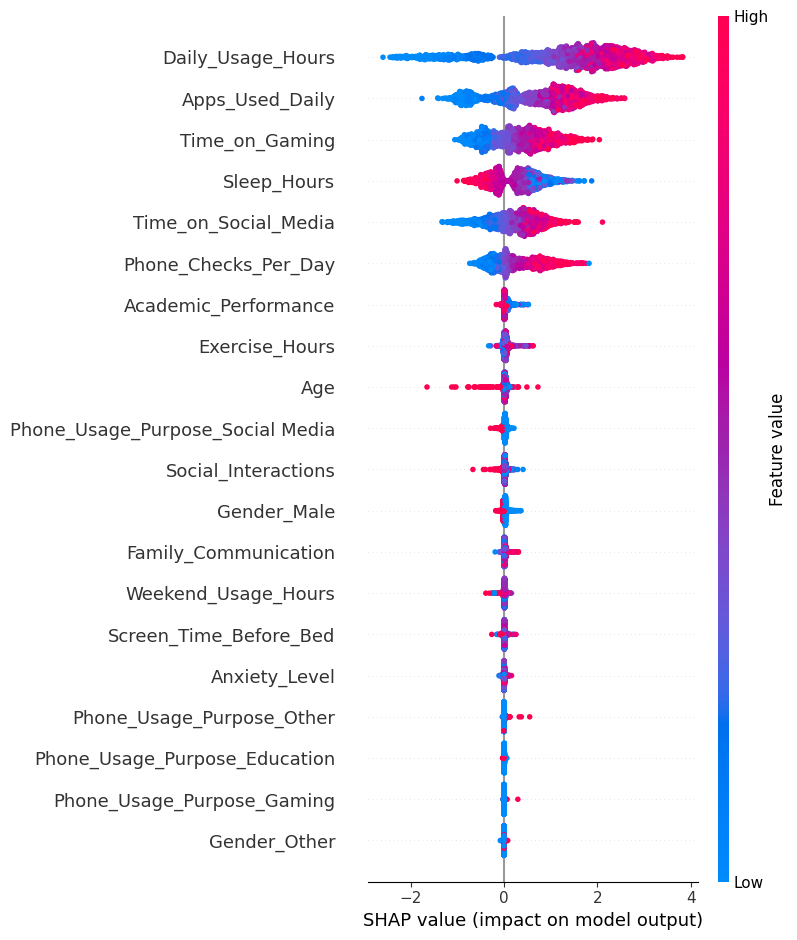

100%|██████████| 50/50 [00:02<00:00, 17.20it/s]


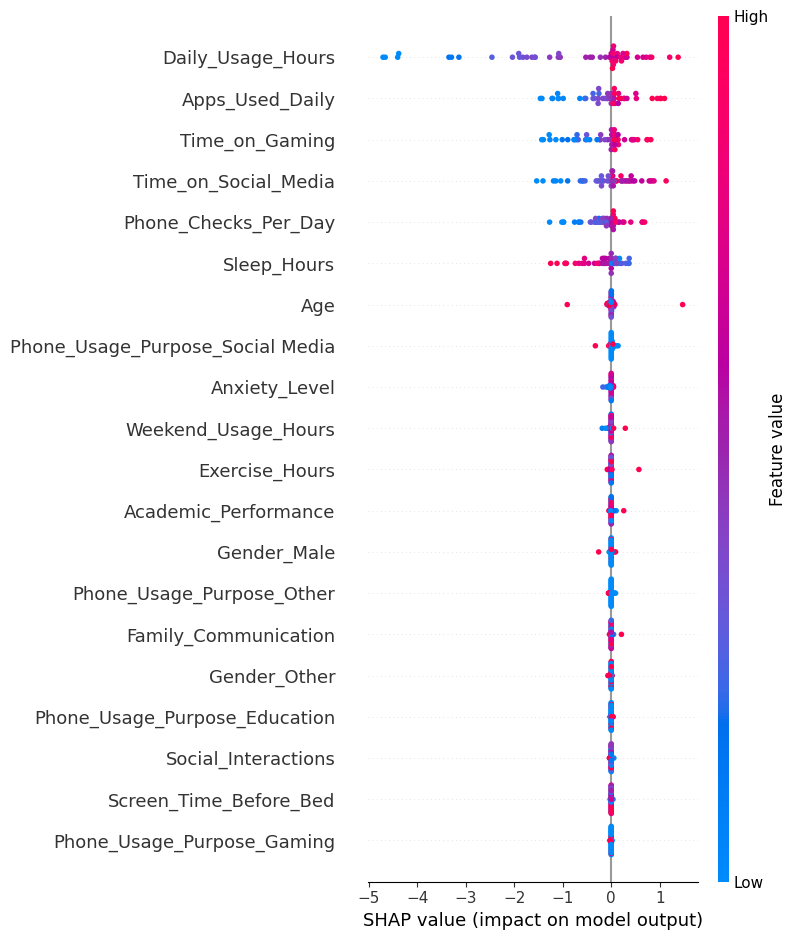

In [8]:
xgb_opt = XGBRegressor(
    max_depth=7,
    learning_rate=0.1,
    random_state=42
)

mlp_opt = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='tanh',
    alpha=0.01,
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

xgb_smote, _ = models.train_final_model(
    xgb_opt, X_train, y_train,
    use_smote=True
)

models.run_shap(xgb_smote, X_train)

mlp_smote, scaler = models.train_final_model(
    mlp_opt, X_train, y_train,
    use_smote=True,
    use_scaling=True
)

models.run_shap(mlp_smote, X_train, scaler, 'kernel')


SHAP analiza za oba modela pokazuje da su najvažniji faktori zavisnosti direktno povezani sa intenzitetom korišćenja telefona, poput dnevnog vremena korišćenja, broja aplikacija i učestalosti provjeravanja telefona. Takođe, manji broj sati sna značajno doprinosi većem nivou zavisnosti, dok demografski i pojedini socijalni faktori imaju zanemarljiv uticaj. Konzistentnost rezultata između XGBoost i MLP modela dodatno potvrđuje pouzdanost ovih zaključaka.

In [9]:
shap_features = ['Daily_Usage_Hours', 'Apps_Used_Daily', 'Time_on_Gaming', 'Time_on_Social_Media', 'Phone_Checks_Per_Day', 'Sleep_Hours', 
                 'Academic_Performance', 'Exercise_Hours', 'Age', 'Phone_Usage_Purpose_Social Media', 'Social_Interactions','Weekend_Usage_Hours']
X_train_reduced = X_train[shap_features]
X_test_reduced = X_test[shap_features]

_ = models.train_model_with_cv(
    xgb_opt,
    X_train_reduced,
    y_train,
    use_smote=True
)

_ = models.train_model_with_cv(
    mlp_opt,
    X_train_reduced,
    y_train,
    use_smote=True,
    use_scaling=True
)


===== XGBRegressor (K-Fold SMOTE) =====
CV MAE: 0.4073 | RMSE: 0.6359 | R2: 0.8600

===== MLPRegressor (K-Fold Scaled + SMOTE) =====
CV MAE: 0.1435 | RMSE: 0.4315 | R2: 0.9308


In [10]:
xgb_standard, _ = models.train_final_model(
    xgb_opt, X_train_reduced, y_train
)

xgb_smote, _ = models.train_final_model(
    xgb_opt, X_train_reduced, y_train,
    use_smote=True
)

xgb_weighted, _ = models.train_final_model(
    xgb_opt, X_train_reduced, y_train,
    use_weights=True
)

mlp_smote, scaler = models.train_final_model(
    mlp_opt, X_train_reduced, y_train,
    use_smote=True,
    use_scaling=True
)


In [11]:
results_xgb_smote = models.evaluate_model(xgb_smote, X_test_reduced, y_test, None, 'SMOTE')
results_xgb_weighted = models.evaluate_model(xgb_weighted, X_test_reduced, y_test, None, 'WEIGHTED')
results_xgb_standard = models.evaluate_model(xgb_standard, X_test_reduced, y_test, None)
results_mlp = models.evaluate_model(mlp_smote, X_test_reduced, y_test, scaler, 'SMOTE+SCALED')


===== XGBRegressor (SMOTE) =====
MAE: 0.3614 | RMSE: 0.5462 | R2: 0.8902 | Adj R2: 0.8887

===== XGBRegressor (WEIGHTED) =====
MAE: 0.3547 | RMSE: 0.5650 | R2: 0.8825 | Adj R2: 0.8809

===== XGBRegressor (Standard) =====
MAE: 0.3413 | RMSE: 0.5490 | R2: 0.8890 | Adj R2: 0.8876

===== MLPRegressor (SMOTE+SCALED) =====
MAE: 0.1219 | RMSE: 0.3723 | R2: 0.9490 | Adj R2: 0.9483


Finalne rezultate prijavljujemo nad optimizovanim modelima koji su se najbolje pokazali. Neuronska mreža sa 3 sloja nam daje R² > 0.94. Sada ćemo razmotriti koliko su SMOTE i težinska regresija doprinele smanjenju grešaka pri nižim nivoima zavisnosti.

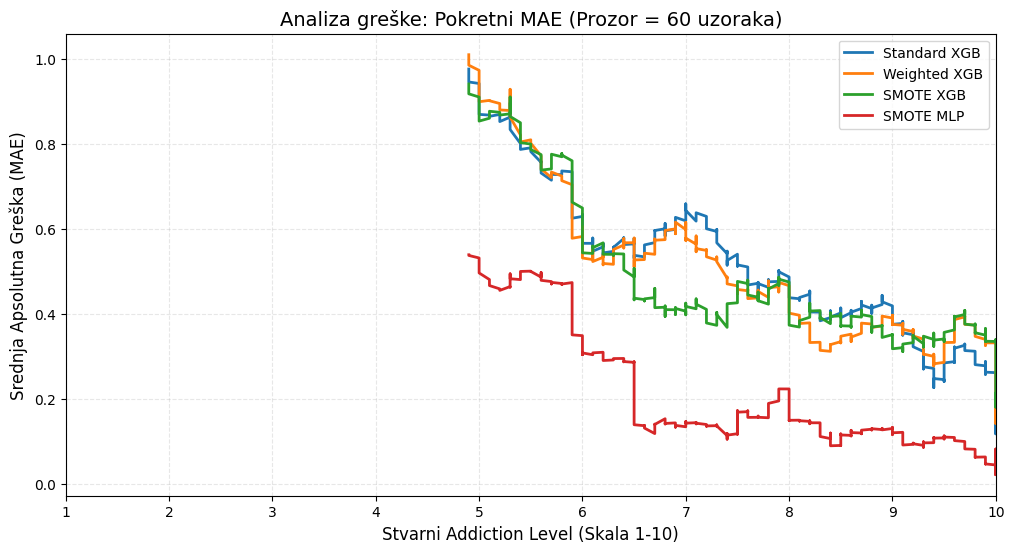

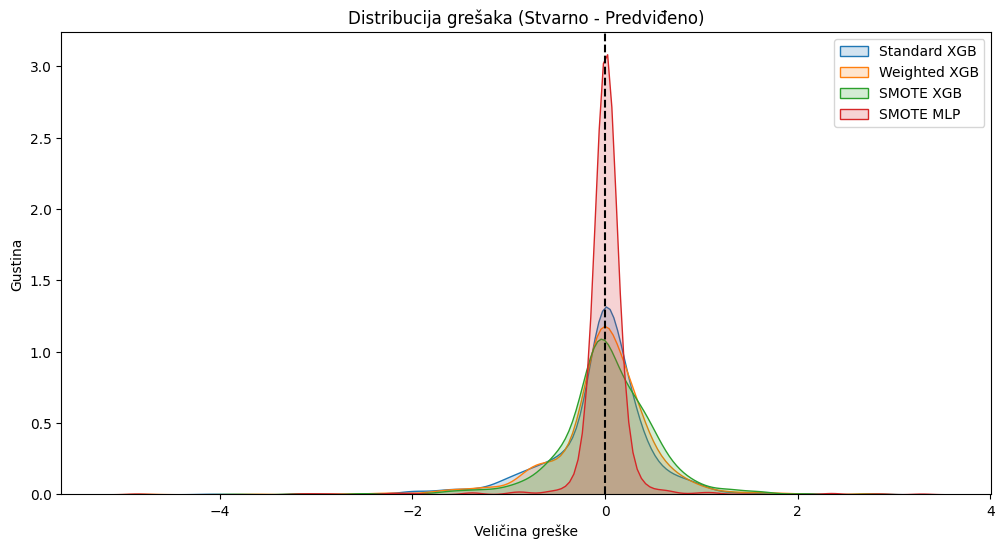

In [12]:
results_dict = {
    "Standard XGB": results_xgb_standard,
    "Weighted XGB": results_xgb_weighted,
    "SMOTE XGB": results_xgb_smote,
    "SMOTE MLP": results_mlp
}

models.plot_compare_rolling_mae(results_dict, window=60)
models.plot_error_distribution(results_dict=results_dict)

Grafikon Pokretnog MAE pokazuje da je optimizovana neuronska mreža postigla drastično nižu grešku u poređenju sa svim varijacijama XGBoost modela. Dok se MAE ostalih modela u opsegu od 5 do 6 kreće između 0.6 i 1.0, MLP uspeva da spusti tu grešku na nivo od 0.4 do 0.6, a u višim opsezima (iznad 6.5) dostiže neverovatnu preciznost sa greškom od svega 0.1 do 0.2.

Grafikon distribucije grešaka dodatno potvrđuje superiornost neuronske mreže. Crvena kriva (MLP) ima najviši i najuži vrh centriran tačno na nuli. U poređenju sa XGBoost varijantama (plava, narandžasta i zelena), MLP ima znatno "tanje repove", što znači da su veliki promašaji svedeni na minimum.